# Appendix B: Elliptic Regularity

    **Source orientation:** McDuff-Salamon, *J-holomorphic Curves and Symplectic Topology*, Appendix B, printed pp. 549-578; PDF pp. 564-593. Sections: B.1-B.4.

    ## Chapter Goal

    Sobolev spaces, Calderon-Zygmund inequality, regularity for the Laplace operator, and elliptic bootstrapping.

    The guiding question is:

    > Why do weak solutions of elliptic equations become smoother once the equation is known?

    ## Computational Translation Guide

    | Chapter language | Computational object | Inspection target / check |
| --- | --- | --- |
| Sobolev norm | frequency-weighted coefficient sum | finite weighted energy |
| elliptic estimate | control of high derivatives by operator and low norm | norm inequality |
| Laplace regularity | divide by frequency squared | two-derivative gain |
| bootstrapping | iterate regularity gain | monotone smoothness levels |
| weak solution | distributional equation | upgraded coefficient decay |


## Standalone Reading Guide

    Elliptic regularity explains why the analytic setup can begin in Sobolev spaces without ending there. Sobolev completions make the implicit function theorem available, but the geometric objects of interest should be smooth curves. Elliptic estimates bridge that gap: if a weak solution satisfies an elliptic equation with smooth data, the equation forces additional derivatives to exist.

The Laplace operator is the cleanest model. In Fourier variables, applying the inverse Laplacian divides each nonzero mode by the square of its frequency. High-frequency roughness is therefore damped. The Cauchy-Riemann type operators in the book are first-order elliptic rather than exactly the scalar Laplacian, but the regularity philosophy is the same.

The experiment starts with rough forcing coefficients and solves a periodic Poisson problem. The plotted coefficients show the two-derivative gain. The ledger compares Sobolev norms before and after solving, making the bootstrapping direction visible: once the right-hand side improves, the solution improves again.

    ## Topics In This Notebook

    - Sobolev norms as weighted Fourier information
- elliptic estimates and derivative control
- Laplace operator regularity
- bootstrapping from weak to smooth solutions
- why curve equations can be studied in Sobolev completions

    ## Visualization Storyboard

    - A Fourier-coefficient plot shows how solving a Laplace equation damps high frequencies.
- A dependency graph connects Sobolev setup, elliptic estimates, and smooth moduli representatives.
- A ledger checks two-derivative gain in a toy periodic model.

For the curve chapters, the practical lesson is that weak analytic control and geometric smoothness are not separate worlds. One completes a space of maps to make analysis possible, solves an equation there, and then uses elliptic regularity to return to smooth geometry. This is why estimates are part of the architecture of the subject: they certify that the moduli points being counted are genuine smooth curves rather than artifacts of a chosen function-space completion.


In [1]:
from pathlib import Path
import csv
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp


def find_book_root(start=None):
    start = (start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        for candidate in [base, base / "J-Holomorphic-Curves-and-Symplectic-Topology"]:
            if (candidate / "AGENTS.md").exists() and (candidate / "utils").exists():
                return candidate
    raise RuntimeError("JHCST book root not found")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib

UNIT = 'appendix-b'
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
TABLE_DIR = ARTIFACT_ROOT / "tables"
HTML_DIR = ARTIFACT_ROOT / "html"
for folder in [FIG_DIR, CHECK_DIR, TABLE_DIR, HTML_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

BOOK_ROOT


WindowsPath('D:/Geometry/J-Holomorphic-Curves-and-Symplectic-Topology')

## Proof Visual: Dependency Map

The graph below is a compact proof-state diagram. Read an arrow as "this idea must be under control before the next one can be used." The point is not to replace the analysis with a graph, but to keep the logical dependencies inspectable while the chapter moves between local equations, moduli spaces, compactness, and algebraic counts.


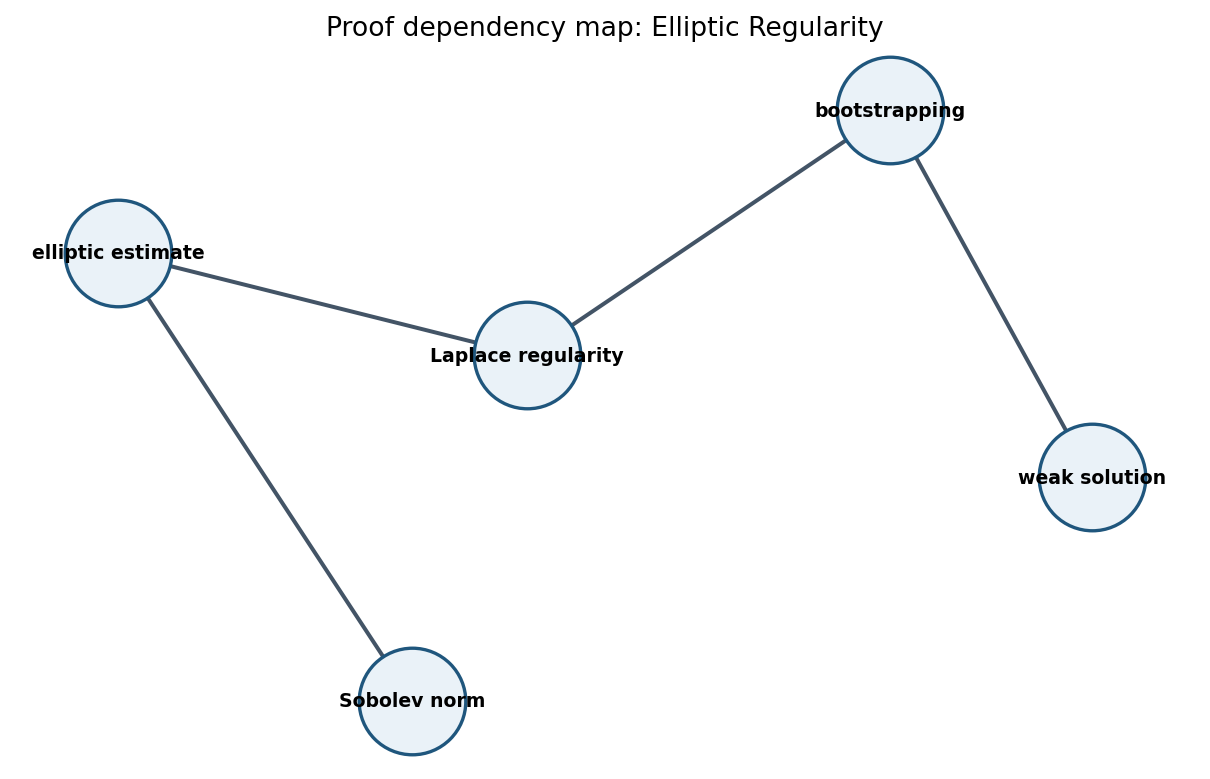

{'nodes': 5,
 'edges': 4,
 'is_directed_acyclic_graph': True,
 'source_span': '549-578',
 'passed': True}

In [2]:
CONCEPT_NODES = ['Sobolev norm', 'elliptic estimate', 'Laplace regularity', 'bootstrapping', 'weak solution']
CONCEPT_EDGES = [('Sobolev norm', 'elliptic estimate'), ('elliptic estimate', 'Laplace regularity'), ('Laplace regularity', 'bootstrapping'), ('bootstrapping', 'weak solution')]

G = nx.DiGraph()
G.add_nodes_from(CONCEPT_NODES)
G.add_edges_from(CONCEPT_EDGES)
pos = nx.spring_layout(G, seed=29, k=1.35)

fig, ax = plt.subplots(figsize=(9.5, 5.8))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=18, width=1.8, edge_color="#435466")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2300, node_color="#eaf2f8", edgecolors="#1f567d", linewidths=1.5)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8.5, font_weight="bold")
ax.set_title('Proof dependency map: Elliptic Regularity')
ax.set_axis_off()
graph_path = save_matplotlib(fig, UNIT, "figures", "proof-dependency-map.png")
plt.close(fig)

graph_check = {
    "nodes": len(CONCEPT_NODES),
    "edges": len(CONCEPT_EDGES),
    "is_directed_acyclic_graph": nx.is_directed_acyclic_graph(G),
    "source_span": '549-578',
    "passed": len(CONCEPT_NODES) >= 5 and nx.is_directed_acyclic_graph(G),
}
graph_json = save_json(graph_check, UNIT, "checks", "proof-dependency-map.json")
display_artifact(graph_path, width=780)
graph_check


## Executable Model

This section builds a small model for one core mechanism in Elliptic Regularity. The model is intentionally finite and inspectable: it creates an artifact, records a JSON check, and gives a learner a parameter to perturb in the applied lab.


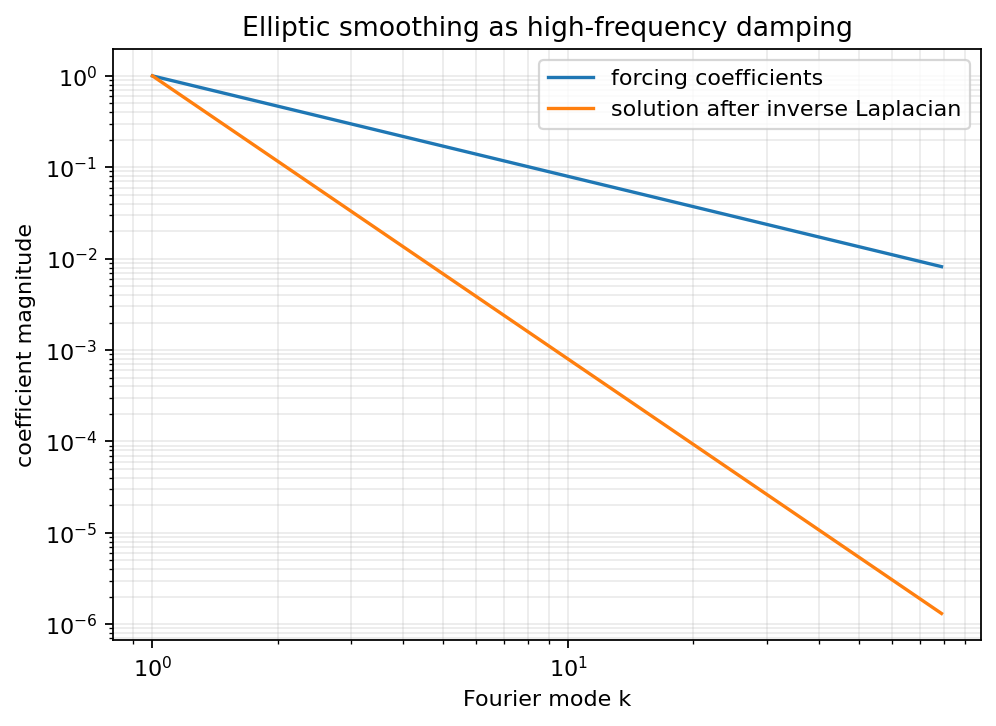

{'forcing_H0': 1.2190875158179513,
 'forcing_H1': 6.49397326687397,
 'solution_H2': 2.154213952338235,
 'solution_H3': 7.026254488173514,
 'tail_gain_ratio': 6241.0,
 'passed': True}

In [3]:
k = np.arange(1, 80)
forcing = 1 / (k ** 1.1)
solution = forcing / (k**2)

def sobolev_norm(coeffs, s):
    return float(np.sqrt(np.sum((1 + k**2) ** s * coeffs**2)))

norms = {
    "forcing_H0": sobolev_norm(forcing, 0),
    "forcing_H1": sobolev_norm(forcing, 1),
    "solution_H2": sobolev_norm(solution, 2),
    "solution_H3": sobolev_norm(solution, 3),
}

fig, ax = plt.subplots(figsize=(7.0, 4.8))
ax.loglog(k, forcing, label="forcing coefficients")
ax.loglog(k, solution, label="solution after inverse Laplacian")
ax.set_xlabel("Fourier mode k")
ax.set_ylabel("coefficient magnitude")
ax.set_title("Elliptic smoothing as high-frequency damping")
ax.legend()
ax.grid(True, which="both", alpha=0.25)
fig_path = save_matplotlib(fig, UNIT, "figures", "elliptic-fourier-smoothing.png")
plt.close(fig)

check = {
    **norms,
    "tail_gain_ratio": float(forcing[-1] / solution[-1]),
    "passed": bool(solution[-1] < forcing[-1] / 1000 and norms["solution_H2"] < norms["forcing_H0"] * 2),
}
check_path = save_json(check, UNIT, "checks", "elliptic-regularity-checks.json")
display_artifact(fig_path, width=680)
check


## Invariant Ledger

The ledger records the chapter vocabulary as computational objects plus explicit checks. It is a small source map inside the notebook: every row names what should be inspected when the figure or experiment is changed.


In [4]:
ledger_rows = [{'item': 'Sobolev norm', 'computational_object': 'frequency-weighted coefficient sum', 'check': 'finite weighted energy'}, {'item': 'elliptic estimate', 'computational_object': 'control of high derivatives by operator and low norm', 'check': 'norm inequality'}, {'item': 'Laplace regularity', 'computational_object': 'divide by frequency squared', 'check': 'two-derivative gain'}, {'item': 'bootstrapping', 'computational_object': 'iterate regularity gain', 'check': 'monotone smoothness levels'}, {'item': 'weak solution', 'computational_object': 'distributional equation', 'check': 'upgraded coefficient decay'}]
table_path = TABLE_DIR / "invariant-ledger.csv"
with table_path.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=["item", "computational_object", "check"])
    writer.writeheader()
    writer.writerows(ledger_rows)

ledger_check = {
    "row_count": len(ledger_rows),
    "items": [row["item"] for row in ledger_rows],
    "has_source_specific_checks": all(row["check"] for row in ledger_rows),
    "passed": len(ledger_rows) >= 5 and all(row["check"] for row in ledger_rows),
}
ledger_json = save_json(ledger_check, UNIT, "checks", "invariant-ledger.json")
display_artifact(table_path)
ledger_check


{'row_count': 5,
 'items': ['Sobolev norm',
  'elliptic estimate',
  'Laplace regularity',
  'bootstrapping',
  'weak solution'],
 'has_source_specific_checks': True,
 'passed': True}

## Applied Lab

Slow the decay of the forcing coefficients. The solution should still gain two derivatives in the Fourier-weighted norm, but the absolute smoothness level will drop.

The intended workflow is to change one parameter, rerun the executable model, and then inspect both the figure and JSON check. If the visual impression and the invariant check disagree, trust the check first and then ask what the visualization is hiding.


## Takeaways

    - Sobolev spaces are a technical staging area, not the final regularity of curves.
- Elliptic estimates convert equation control into derivative control.
- Bootstrapping just repeats the same gain after the coefficients improve.

    ## Sanity Checks

    The final cell asserts that the generated figures, ledgers, and JSON checks exist, are nonempty, and report successful chapter-specific invariants.


In [5]:
expected = [
    FIG_DIR / "proof-dependency-map.png",
    FIG_DIR / 'elliptic-fourier-smoothing.png',
    CHECK_DIR / "proof-dependency-map.json",
    CHECK_DIR / 'elliptic-regularity-checks.json',
    CHECK_DIR / "invariant-ledger.json",
    TABLE_DIR / "invariant-ledger.csv",
]
for path in expected:
    min_bytes = 80 if path.suffix == ".csv" else 512
    assert_artifact(path, min_bytes=min_bytes)

for path in [CHECK_DIR / "proof-dependency-map.json", CHECK_DIR / 'elliptic-regularity-checks.json', CHECK_DIR / "invariant-ledger.json"]:
    data = json.loads(path.read_text(encoding="utf-8"))
    assert data.get("passed") is True, path

print(f"Validated {len(expected)} artifacts for {UNIT}")


Validated 6 artifacts for appendix-b
